# 07 — Beyond Confounders

**통제변수를 무조건 많이 넣으면 좋을까? 교란변수 너머의 이야기**

---

교란변수(Confounder)를 통제해야 한다는 건 알겠는데, 그 외의 변수들은 어떻게 해야 할까요? 많이 넣을수록 좋다고 생각하기 쉽지만, 변수에 따라 효과를 더 정밀하게 추정해주기도 하고, 오히려 표준오차를 키우거나, 심지어 편향을 만들어내기도 합니다.

이 챕터에서는 통제변수를 세 가지 유형으로 나눠서 살펴봅니다.

In [1]:
import pandas as pd
import numpy as np
from scipy.special import expit
import statsmodels.formula.api as smf
import graphviz as gr
import os

np.random.seed(42)
os.environ["PATH"] += os.pathsep + r"C:\Program Files\Graphviz\bin"

---

## 1. 좋은 통제변수 — 결과(Y)를 잘 예측하는 변수

핀테크 회사에서 연체 고객에게 이메일을 보내는 실험을 합니다. 5,000명에게 무작위로 이메일(처치)을 발송하고, 이것이 지불금액(결과)에 미치는 효과를 분석합니다. 이메일은 무작위 배정이므로 단순히 이메일 받은 사람과 안 받은 사람의 평균 차이로 ATE를 추정할 수 있을 것 같습니다.

그런데 데이터에는 두 가지 변수가 더 있습니다. `credit_limit`(신용한도)과 `risk_score`(리스크 점수)입니다. 이 변수들은 이메일 발송 여부와 무관합니다(무작위 배정이니까요). 하지만 지불금액을 매우 잘 예측합니다. 신용한도가 높은 고객은 원래 지불금액이 많고, 리스크 점수가 높은 고객은 적습니다.

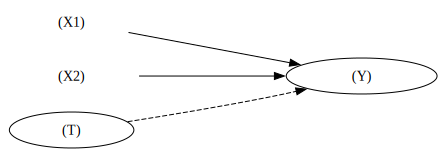

In [2]:
g = gr.Digraph()
g.attr(rankdir="LR")
with g.subgraph() as s:
    s.attr(rank="same")
    s.node("X1", "신용한도 (X1)", shape="plaintext")
    s.node("X2", "리스크 점수 (X2)", shape="plaintext")
g.node("T", "이메일 (T)")
g.node("Y", "지불금액 (Y)")
g.edge("X1", "Y")
g.edge("X2", "Y")
g.edge("T", "Y", style="dashed", label="알고 싶은 효과")
g

DAG를 보면, 신용한도와 리스크 점수는 이메일의 원인이 아닙니다. 처치(T)로 가는 화살표가 없으니 교란변수가 아닙니다. 그렇다면 모델에 넣어야 할까요?

### FWL(Frisch-Waugh-Lovell) 정리

통계학의 강력한 결과 중 하나입니다. 회귀모형에 통제변수를 추가하는 것은, 처치와 결과 각각에서 그 통제변수의 영향을 제거한 잔차끼리 회귀하는 것과 정확히 동일합니다.

$$\tilde{Y} = Y - \hat{Y}_{controls}, \qquad \tilde{T} = T - \hat{T}_{controls}$$

$$\hat{\kappa}_{FWL} = \frac{Cov(\tilde{T},\, \tilde{Y})}{Var(\tilde{T})}$$

신용한도와 리스크 점수가 지불금액 분산의 상당 부분을 설명합니다. 이것들을 통제하면 $\tilde{Y}$의 분산이 크게 줄어들고, 결과적으로 이메일 계수의 **표준오차(SE)가 감소**합니다. 추정치 자체는 거의 변하지 않지만, 훨씬 정밀해집니다.

In [3]:
n = 5000
credit_limit = np.random.gamma(2, 300, n).round()
risk_score = np.random.beta(2, 5, n).round(2)
email = np.random.binomial(1, 0.5, n)
payments = (300 + 0.3 * credit_limit - 400 * risk_score
            + 5 * email + np.random.normal(0, 50, n))
payments = np.maximum(0, payments).round()

data = pd.DataFrame(dict(
    payments=payments, email=email,
    credit_limit=credit_limit, risk_score=risk_score
))

m_simple = smf.ols("payments ~ email", data=data).fit()
m_ctrl = smf.ols("payments ~ email + credit_limit + risk_score", data=data).fit()

resid_Y = smf.ols("payments ~ credit_limit + risk_score", data=data).fit().resid
resid_T = smf.ols("email ~ credit_limit + risk_score", data=data).fit().resid
fwl = smf.ols("resid_Y ~ resid_T",
              data=pd.DataFrame({"resid_Y": resid_Y, "resid_T": resid_T})).fit()

pd.DataFrame({
    "모델": ["통제 없음", "통제 추가", "FWL"],
    "email 계수": [m_simple.params["email"], m_ctrl.params["email"], fwl.params["resid_T"]],
    "SE": [m_simple.bse["email"], m_ctrl.bse["email"], fwl.bse["resid_T"]]
}).round(4)

,모델,email 계수,SE
0,통제 없음,-2.7232,4.2340
1,통제 추가,4.0550,1.3988
2,FWL,4.0550,1.3985


계수는 거의 동일하지만 SE가 크게 줄어든 것을 확인할 수 있습니다. 통제 없이는 p값이 0.07로 유의하지 않았던 것이 통제 후에는 p < 0.001로 명확해집니다.

> **좋은 통제변수의 조건**  
> 결과(Y)를 잘 예측하는 변수라면, 처치(T)와 무관하더라도 모델에 추가할 가치가 있습니다. SE를 줄여서 같은 샘플 크기로 더 정밀한 추정을 할 수 있기 때문입니다. ATE 추정치 자체는 바뀌지 않습니다.

---

## 2. 해로운 통제변수 — 처치(T)만 예측하는 변수

두 병원에서 신약 실험을 합니다. 진짜 약을 복용하면 입원 기간이 줄어들 것입니다. 병원 A는 주로 경증 환자를 받고 10%에게만 진짜 약을 투여하며, 병원 B는 주로 중증 환자를 받고 90%에게 진짜 약을 투여합니다.

교란변수는 **중증도(severity)** 입니다. 중증도가 높으면 입원 기간도 길고, 진짜 약을 받을 확률도 높습니다. 그렇다면 `hospital`(병원) 변수는 어떨까요? 병원은 처치를 잘 예측하지만, 중증도를 통제하고 나면 입원 기간과 무관합니다.

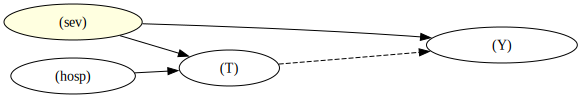

In [4]:
g2 = gr.Digraph()
g2.attr(rankdir="LR")
g2.node("sev", "중증도 (sev)", style="filled", fillcolor="lightyellow")
g2.node("hosp", "병원 (hosp)")
g2.node("T", "처치 (T)")
g2.node("Y", "입원일수 (Y)")
g2.edge("sev", "T")
g2.edge("sev", "Y")
g2.edge("hosp", "T")
g2.edge("T", "Y", style="dashed", label="알고 싶은 효과")
g2

In [5]:
n_h = 100
hospital = np.array([0]*n_h + [1]*n_h)
severity = np.concatenate([
    np.random.normal(10, 3, n_h),
    np.random.normal(20, 3, n_h)
])
treatment = np.concatenate([
    np.random.binomial(1, 0.1, n_h),
    np.random.binomial(1, 0.9, n_h)
])
days = np.maximum(1, 20 - 8*treatment + 2*severity + np.random.normal(0, 5, 2*n_h))

hosp_data = pd.DataFrame(dict(
    days=days.round(1), treatment=treatment,
    severity=severity.round(1), hospital=hospital
))

m1 = smf.ols("days ~ treatment", data=hosp_data).fit()
m2 = smf.ols("days ~ treatment + severity", data=hosp_data).fit()
m3 = smf.ols("days ~ treatment + severity + hospital", data=hosp_data).fit()

pd.DataFrame({
    "모델": ["통제 없음", "중증도 통제", "중증도 + 병원"],
    "treatment 계수": [m1.params["treatment"], m2.params["treatment"], m3.params["treatment"]],
    "SE": [m1.bse["treatment"], m2.bse["treatment"], m3.bse["treatment"]]
}).round(3)

,모델,treatment 계수,SE
0,통제 없음,7.654,1.374
1,중증도 통제,-9.230,0.917
2,중증도 + 병원,-9.593,1.098


병원을 추가하면 계수는 비슷하지만 SE가 커집니다. 표준오차 공식의 분모에는 처치 변수의 분산이 있는데, `hospital`을 추가하면 같은 병원 내에서의 처치 변동만 남아 유효 분산이 줄어들기 때문입니다.

> **해로운 통제변수의 조건**  
> 처치(T)만 예측하고 결과(Y)와는 무관한 변수는 넣지 않는 게 낫습니다. 계수는 비슷하게 유지되지만 SE가 불필요하게 커져서 통계적 검정력이 떨어집니다.

---

## 3. 나쁜 통제변수 — 선택 편향을 만들어내는 변수

### 3-1. 처치(T) 이후에 발생하는 변수

다시 이메일 실험으로 돌아옵니다. 이번엔 두 가지 변수를 추가로 살펴봅니다.

- `opened`: 이메일을 열었는지 여부
- `agreement`: 이메일 수신 후 부서에 연락해 채무 협상을 한 경우

직관적으로 생각해보면, 이메일을 받지 않으면 열 수 없습니다. `agreement`도 이메일 수신 후에 가능합니다. 이 변수들은 이메일이 원인이 되어 발생한 결과입니다.

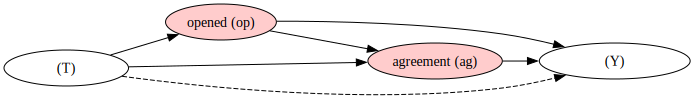

In [6]:
g3 = gr.Digraph()
g3.attr(rankdir="LR")
g3.node("T", "이메일 (T)")
g3.node("op", "opened (op)", style="filled", fillcolor="#ffcccc")
g3.node("ag", "agreement (ag)", style="filled", fillcolor="#ffcccc")
g3.node("Y", "지불금액 (Y)")
g3.edge("T", "op")
g3.edge("T", "ag")
g3.edge("op", "ag")
g3.edge("op", "Y")
g3.edge("ag", "Y")
g3.edge("T", "Y", style="dashed", label="총 효과")
g3

만약 `agreement`를 통제하면, 우리는 사실 이렇게 묻는 것입니다. *"agreement가 고정되었을 때, 이메일의 효과는?"* 하지만 이메일이 지불금액을 높이는 핵심 경로 중 하나가 agreement를 늘리는 것인데, 그 경로를 막아버리면 이메일의 실제 효과가 과소추정됩니다.

더 심각한 문제가 있습니다. `agreement=0`인 사람들을 비교한다고 해봅시다.

- **T=0, agreement=0:** 이메일을 못 받아서 agreement를 못 한 사람 (성실하지만 기회가 없었던 채무자 포함)
- **T=1, agreement=0:** 이메일을 받고도 agreement를 하지 않은 사람 (완강하게 거부한 채무자)

같은 `agreement=0`이지만 전혀 다른 유형입니다. 무작위 배정이어도 `agreement`를 조건으로 걸면 두 그룹이 더 이상 비교 가능하지 않습니다. 이것이 **선택 편향(Selection Bias)** 입니다.

> **나쁜 통제변수 유형 1: 처치 경로 위의 변수**  
> T → opened → agreement → Y처럼, 처치에서 결과로 가는 경로 위에 있는 변수는 절대 통제하면 안 됩니다.

In [7]:
credit_limit = np.random.gamma(2, 300, n).round()
risk_score = np.random.beta(2, 5, n).round(2)
email = np.random.binomial(1, 0.5, n)
opened = np.random.binomial(1, np.where(email==1, 0.7, 0.01), n)
agreement = np.random.binomial(1, expit(-2 + 3*opened + email), n)
payments = (300 + 0.3*credit_limit - 400*risk_score
            + 5*email + 10*opened + 20*agreement
            + np.random.normal(0, 50, n))
payments = np.maximum(0, payments).round()

bad_data = pd.DataFrame(dict(
    payments=payments, email=email,
    opened=opened, agreement=agreement,
    credit_limit=credit_limit, risk_score=risk_score
))

m_ok = smf.ols("payments ~ email + credit_limit + risk_score", data=bad_data).fit()
m_open = smf.ols("payments ~ email + opened + credit_limit + risk_score", data=bad_data).fit()
m_agree = smf.ols("payments ~ email + agreement + credit_limit + risk_score", data=bad_data).fit()

pd.DataFrame({
    "모델": ["올바른 모델", "opened 추가", "agreement 추가"],
    "email 계수": [m_ok.params["email"], m_open.params["email"], m_agree.params["email"]]
}).round(3)

,모델,email 계수
0,올바른 모델,24.760
1,opened 추가,6.587
2,agreement 추가,8.802


처치 경로 위의 변수를 통제할수록 이메일 효과 추정치가 줄어드는 것을 확인할 수 있습니다.

---

### 3-2. Bad COP (Conditional on Positives)

마케팅 캠페인이 고객 지출에 미치는 효과를 분석합니다. 데이터를 열어보니 구매하지 않은 고객($Y=0$)이 엄청나게 많습니다. 일부 분석가들은 "0이 너무 많아서 분석이 어렵다"며 구매자($Y > 0$)만 걸러서 분석합니다. 이것이 **COP(Conditional on Positives)** 입니다.

고객을 두 종류로 나눠서 생각해봅시다.

- **부유한 고객(rich):** 캠페인이 없어도 어차피 삽니다. 항상 $Y > 0$.
- **절약형 고객(frugal):** 캠페인이 있어야만 삽니다. 캠페인 없으면 $Y = 0$.

$Y > 0$인 고객만 보면 처치군에는 frugal 고객이 섞여있고(소득 낮음), 통제군은 모두 rich 고객입니다. 이 두 그룹은 처음부터 달랐습니다.

> **나쁜 통제변수 유형 2: Bad COP**  
> $Y > 0$만 골라서 분석하는 것은 처치 결과에 의해 만들어진 선택 편향입니다. 0이 많아서 불편하더라도, 0은 중요한 정보입니다.

In [8]:
n = 2000
marketing = np.random.binomial(1, 0.5, n)
rich = np.random.binomial(1, 0.3, n)
spend = np.where(
    rich == 1,
    np.random.normal(300, 50, n),
    np.where(marketing==1, np.random.normal(200, 50, n), 0)
)
spend = np.maximum(0, spend).round()
cop_data = pd.DataFrame(dict(spend=spend, marketing=marketing, rich=rich))

ate_correct = cop_data.groupby("marketing")["spend"].mean().diff().iloc[-1]
buyers = cop_data[cop_data["spend"] > 0]
ate_cop = buyers.groupby("marketing")["spend"].mean().diff().iloc[-1]

pd.DataFrame({
    "분석 방법": ["전체 데이터 (올바른 ATE)", "Bad COP (구매자만)"],
    "추정 ATE": [ate_correct, ate_cop]
}).round(1)

,분석 방법,추정 ATE
0,전체 데이터 (올바른 ATE),138.2
1,Bad COP (구매자만),-69.7


---

## 핵심 정리

통제변수를 결정할 때는 항상 **인과 그래프(DAG)를 먼저 그려보세요.** 그래프 없이 통계적 직관만으로 판단하면 실수할 가능성이 높습니다.

| 변수 종류 | 특징 | 판단 |
|:---|:---|:---|
| 교란변수 | T와 Y 모두의 원인 | 반드시 통제 |
| Y 예측 변수 | Y를 잘 예측, T와 무관 | SE 감소 효과 |
| T만 예측 | T의 원인이지만 Y와 무관 | 안 넣는 게 나음 |
| T의 결과 | T → 변수 → Y 경로 위 | 절대 금지 |
| Y 필터링(COP) | $Y > 0$ 조건부 분석 | 절대 금지 |

---
*참고: Matheus Facure, Python Causality Handbook, Chapter 07 — Beyond Confounders*